In [1]:
import numpy as np
import matplotlib.pyplot as plt
import EFC_learningfMRI.globals as gl
import PcmPy as pcm
import pandas as pd
from scipy.stats import linregress
import os
import itertools
import seaborn as sb
import statsmodels.formula.api as smf
from EFC_learningfMRI.vis import plot_ci_im_sess

base directory found: /cifs/diedrichsen/data/Chord_exp/EFC_learningfMRI
Atlas directory found: atlases
figure directory found: figures/


In [2]:
behav            = pd.read_csv(os.path.join(gl.baseDir, gl.behavDir, 'behaviour.session.success.tsv'), sep='\t')
behav            = behav[behav.session.isin([3, 9, 23])].reset_index(drop=True)
behav_trained    = behav[behav.chord=='trained'].reset_index(drop=True)
behav_untrained  = behav[behav.chord=='untrained'].reset_index(drop=True)
diff_behav       = behav_trained.copy()
diff_behav       = diff_behav.merge(behav_untrained, on=['subNum', 'session'])
diff_behav['ET'] = diff_behav.ET_x - diff_behav.ET_y
diff_behav['MD'] = diff_behav.MD_x - diff_behav.MD_y

In [3]:
H     = 'L'
atlas = 'ROI'
rois  = gl.rois[atlas]
glm   = 3
stat  = 'crossnobis'
dist             = pd.read_csv(os.path.join(gl.baseDir, gl.pcmDir, f'dissimilarity.within_session.ROI.glm{glm}.tsv'), sep='\t')
dist             = dist[(dist.Hem=='L') & (dist.chord.isin(['trained', 'untrained']))]
dist_chord_sess  = dist.groupby(['sn', 'Hem', 'roi', 'session', 'chord']).mean(numeric_only=True).reset_index()
dist_trained     = dist_chord_sess[dist_chord_sess.chord=='trained'].reset_index(drop=True)
dist_untrained   = dist_chord_sess[dist_chord_sess.chord=='untrained'].reset_index(drop=True)
diff_sep         = dist_trained.copy()
diff_sep         = diff_sep.merge(dist_untrained, on=['session', 'sn', 'roi', 'Hem'])
diff_sep['Diff'] = diff_sep[f'{stat}_x'] - diff_sep[f'{stat}_y']

diff_sep = diff_sep[diff_sep.sn!=117]

In [10]:
dist

,sn,Hem,roi,session,chord,pair,crossnobis,cosine,crossnobis_group,cosine_group,theta,theta_group
0,101,L,SMA,3,trained,22911-91211,0.004491,0.958252,0.026219,0.984049,0.289970,0.178851
1,101,L,SMA,3,trained,91211-92122,0.001923,0.971758,0.067730,0.964775,0.238228,0.266209
2,101,L,SMA,3,trained,22911-92122,0.002859,0.977340,0.037088,0.978402,0.213289,0.208211
3,101,L,SMA,3,trained,12291-91211,0.002579,0.966958,0.039332,0.978456,0.257781,0.207950
4,101,L,SMA,3,trained,12291-22911,0.003278,0.966582,0.026598,0.981690,0.259250,0.191656
...,...,...,...,...,...,...,...,...,...,...,...,...
8211,117,L,SPLp,23,untrained,21291-22911,0.098402,0.963443,0.075069,0.964673,0.271227,0.266598
8212,117,L,SPLp,23,untrained,12291-21291,0.009874,0.997366,0.030210,0.982966,0.072594,0.184836
8213,117,L,SPLp,23,untrained,12129-22911,0.274069,0.906176,0.185083,0.916699,0.436644,0.411058
8214,117,L,SPLp,23,untrained,12129-12291,0.136410,0.956016,0.069067,0.966332,0.297692,0.260225


   regionname  session  intercept    ci_low   ci_high      tval      pval
0         SMA        3  -0.002890 -0.019753  0.013972 -0.377271  0.713149
3         PMd        3  -0.000461 -0.017544  0.016622 -0.059435  0.953672
6         PMv        3  -0.013495 -0.036545  0.009554 -1.288639  0.223967
9          M1        3  -0.000457 -0.048587  0.047673 -0.020894  0.983704
12         S1        3  -0.004807 -0.037211  0.027597 -0.326489  0.750182
15       SPLa        3  -0.009598 -0.040743  0.021547 -0.678309  0.511593
18       SPLp        3  -0.005116 -0.042005  0.031773 -0.305259  0.765868
1         SMA        9   0.039560  0.005539  0.073581  2.559323  0.026551
4         PMd        9   0.032329 -0.008481  0.073139  1.743574  0.109076
7         PMv        9   0.042743 -0.014423  0.099908  1.645669  0.128076
10         M1        9   0.025254 -0.063964  0.114473  0.623016  0.545974
13         S1        9   0.043892 -0.030074  0.117858  1.306087  0.218175
16       SPLa        9   0.051221  0.0

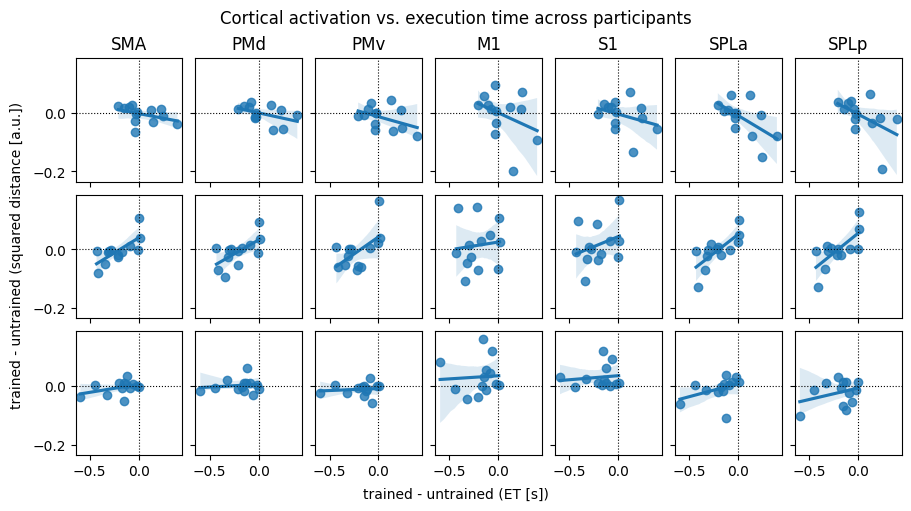

In [4]:
lin_model = {(roi, sess): [] for roi, sess in itertools.product(rois, gl.sessions)}

fig, axs = plt.subplots(len(gl.sessions), len(rois), constrained_layout=True, sharex=True, sharey=True, figsize=(9, 5))

for r, roi in enumerate(rois):
        for s, sess in enumerate(gl.sessions):
                ax = axs[s, r]
                y    = diff_sep[(diff_sep.Hem==H) & (diff_sep.roi==roi) & (diff_sep.session==sess)].Diff.to_numpy()
                x    = diff_behav[diff_behav.session==sess].ET.to_numpy()
                data = pd.DataFrame(np.c_[x, y], columns=['force', 'neural'])

                lin_model[(roi, sess)] = smf.ols('y~x', data=data).fit()

                sb.regplot(data, x='force', y='neural', ax=ax)

                ax.set_title(roi if s==0 else None)
                ax.set_ylabel(None)
                ax.set_xlabel(None)
                ax.axhline(0, color='k', lw=.8, ls=':')
                ax.axvline(0, color='k', lw=.8, ls=':')

fig.supylabel('trained - untrained (squared distance [a.u.])', fontsize=10)
fig.supxlabel('trained - untrained (ET [s])', fontsize=10)

fig.suptitle('Cortical activation vs. execution time across participants')

records = []
for (roi, sess), res in lin_model.items():
        lo, hi = res.conf_int().loc['Intercept']
        records.append({
                'regionname': roi,
                'session':    sess,
                'intercept':  res.params['Intercept'],
                'ci_low':     lo,
                'ci_high':    hi,
                'tval':       res.tvalues['Intercept'],
                'pval':       res.pvalues['Intercept'],
        })
intercepts               = pd.DataFrame(records)
intercepts['regionname'] = pd.Categorical(intercepts.regionname, categories=gl.rois[atlas], ordered=True)
intercepts.sort_values(by=['session', 'regionname'], inplace=True)
print(intercepts)

plt.show()

   regionname  session  intercept    ci_low   ci_high      tval      pval
0         SMA        3  -0.005481 -0.023287  0.012325 -0.677540  0.512062
3         PMd        3  -0.003779 -0.021277  0.013719 -0.475355  0.643833
6         PMv        3  -0.017686 -0.041413  0.006041 -1.640582  0.129139
9          M1        3  -0.007620 -0.055287  0.040047 -0.351850  0.731599
12         S1        3  -0.009355 -0.040831  0.022121 -0.654136  0.526464
15       SPLa        3  -0.018797 -0.051784  0.014190 -1.254199  0.235767
18       SPLp        3  -0.013373 -0.050170  0.023425 -0.799861  0.440723
1         SMA        9   0.025286 -0.013446  0.064018  1.436926  0.178568
4         PMd        9   0.019221 -0.024074  0.062517  0.977145  0.349498
7         PMv        9   0.033713 -0.022131  0.089557  1.328724  0.210844
10         M1        9   0.021401 -0.062327  0.105129  0.562566  0.585013
13         S1        9   0.043530 -0.025027  0.112087  1.397496  0.189812
16       SPLa        9   0.031643 -0.0

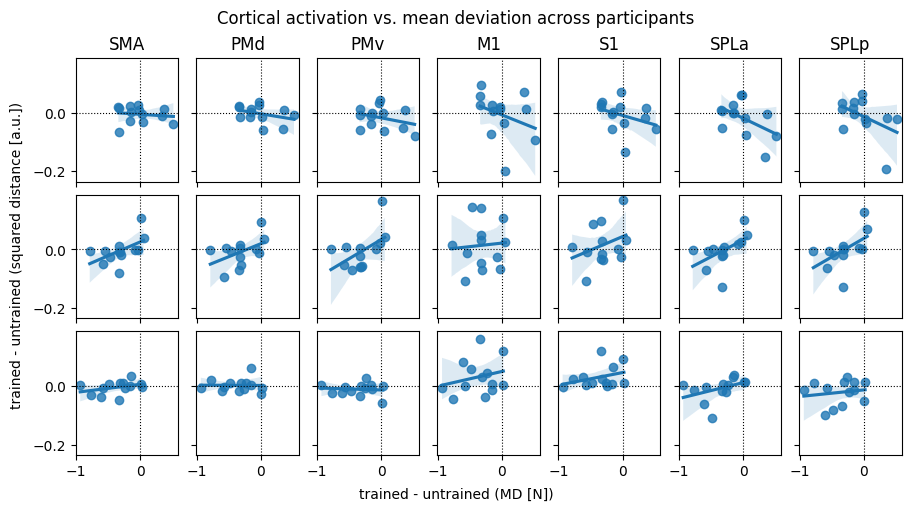

In [5]:
lin_model = {(roi, sess): [] for roi, sess in itertools.product(rois, gl.sessions)}

fig, axs = plt.subplots(len(gl.sessions), len(rois), constrained_layout=True, sharex=True, sharey=True, figsize=(9, 5))

for r, roi in enumerate(rois):
        for s, sess in enumerate(gl.sessions):
                ax = axs[s, r]
                y    = diff_sep[(diff_sep.Hem==H) & (diff_sep.roi==roi) & (diff_sep.session==sess)].Diff.to_numpy()
                x    = diff_behav[diff_behav.session==sess].MD.to_numpy()
                data = pd.DataFrame(np.c_[x, y], columns=['force', 'neural'])

                lin_model[(roi, sess)] = smf.ols('y~x', data=data).fit()

                sb.regplot(data, x='force', y='neural', ax=ax)

                ax.set_title(roi if s==0 else None)
                ax.set_ylabel(None)
                ax.set_xlabel(None)
                ax.axhline(0, color='k', lw=.8, ls=':')
                ax.axvline(0, color='k', lw=.8, ls=':')

fig.supylabel('trained - untrained (squared distance [a.u.])', fontsize=10)
fig.supxlabel('trained - untrained (MD [N])', fontsize=10)

fig.suptitle('Cortical activation vs. mean deviation across participants')

records = []
for (roi, sess), res in lin_model.items():
        lo, hi = res.conf_int().loc['Intercept']
        records.append({
                'regionname': roi,
                'session':    sess,
                'intercept':  res.params['Intercept'],
                'ci_low':     lo,
                'ci_high':    hi,
                'tval':       res.tvalues['Intercept'],
                'pval':       res.pvalues['Intercept'],
        })
intercepts               = pd.DataFrame(records)
intercepts['regionname'] = pd.Categorical(intercepts.regionname, categories=gl.rois[atlas], ordered=True)
intercepts.sort_values(by=['session', 'regionname'], inplace=True)
print(intercepts)

plt.show()

In [6]:
force                        = pd.read_csv(os.path.join(gl.baseDir, gl.behavDir, 'force.session.success.tsv'), sep='\t')
force                        = force[force.session.isin([3, 9, 23])].reset_index(drop=True)
force_trained                = force[force.chord=='trained'].reset_index(drop=True)
force_untrained              = force[force.chord=='untrained'].reset_index(drop=True)
force_diff                   = force_trained.copy()
force_diff                   = force_diff.merge(force_untrained, on=['subNum', 'session'])
force_diff['force_abs']      = force_diff.force_abs_x - force_diff.force_abs_y
force_diff['force_der']      = force_diff.force_der_x - force_diff.force_der_y
force_diff['force_der_peak'] = force_diff.force_der_peak_x - force_diff.force_der_peak_y

     roi  session  intercept    ci_low   ci_high      tval      pval
0    SMA        3  -0.005754 -0.024072  0.012564 -0.691409  0.503639
3    PMd        3  -0.003795 -0.022747  0.015158 -0.440682  0.667978
6    PMv        3  -0.018319 -0.043435  0.006797 -1.605321  0.136725
9     M1        3  -0.001721 -0.051204  0.047761 -0.076561  0.940347
12    S1        3  -0.005665 -0.038892  0.027561 -0.375289  0.714581
15  SPLa        3  -0.021161 -0.057762  0.015439 -1.272546  0.229419
18  SPLp        3  -0.016044 -0.055852  0.023764 -0.887090  0.394012
1    SMA        9   0.001061 -0.025372  0.027493  0.088322  0.931208
4    PMd        9  -0.004119 -0.033612  0.025374 -0.307397  0.764283
7    PMv        9   0.002939 -0.031024  0.036901  0.190462  0.852416
10    M1        9   0.016021 -0.037150  0.069193  0.663183  0.520869
13    S1        9   0.020208 -0.024072  0.064488  1.004474  0.336735
16  SPLa        9   0.000265 -0.034440  0.034971  0.016824  0.986878
19  SPLp        9   0.004668 -0.03

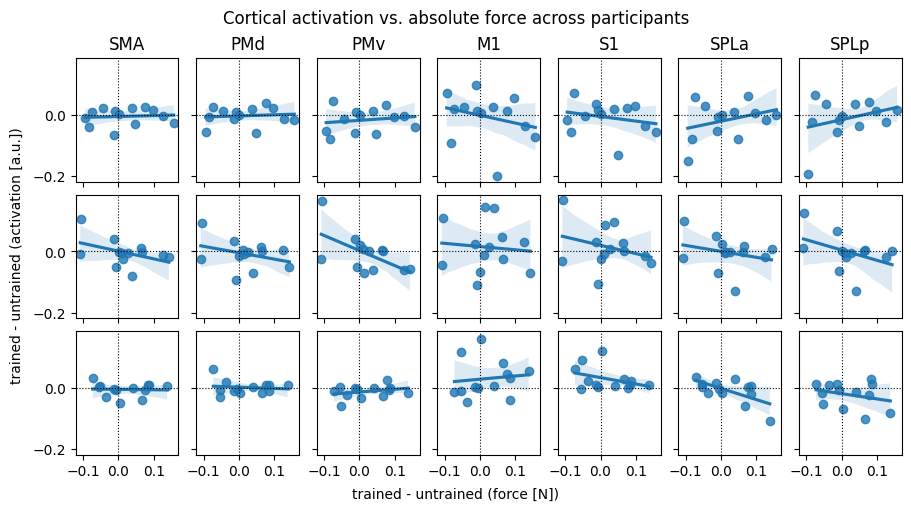

In [7]:
lin_model = {(roi, sess): [] for roi, sess in itertools.product(rois, gl.sessions)}

fig, axs = plt.subplots(len(gl.sessions), len(rois), constrained_layout=True, sharex=True, sharey=True, figsize=(9, 5))

for r, roi in enumerate(rois):
        for s, sess in enumerate(gl.sessions):
                ax = axs[s, r]
                y    = diff_sep[(diff_sep.Hem==H) & (diff_sep.roi==roi) & (diff_sep.session==sess)].Diff.to_numpy()
                x    = force_diff[force_diff.session==sess].force_abs.to_numpy()
                data = pd.DataFrame(np.c_[x, y], columns=['force', 'neural'])

                lin_model[(roi, sess)] = smf.ols('y~x', data=data).fit()

                sb.regplot(data, x='force', y='neural', ax=ax)

                ax.set_title(roi if s==0 else None)
                ax.set_ylabel(None)
                ax.set_xlabel(None)
                ax.axhline(0, color='k', lw=.8, ls=':')
                ax.axvline(0, color='k', lw=.8, ls=':')

fig.supylabel('trained - untrained (activation [a.u.])', fontsize=10)
fig.supxlabel('trained - untrained (force [N])', fontsize=10)

fig.suptitle('Cortical activation vs. absolute force across participants')

records = []
for (roi, sess), res in lin_model.items():
        lo, hi = res.conf_int().loc['Intercept']
        records.append({
                'roi': roi,
                'session':    sess,
                'intercept':  res.params['Intercept'],
                'ci_low':     lo,
                'ci_high':    hi,
                'tval':       res.tvalues['Intercept'],
                'pval':       res.pvalues['Intercept'],
        })
intercepts               = pd.DataFrame(records)
intercepts['roi'] = pd.Categorical(intercepts.roi, categories=gl.rois[atlas], ordered=True)
intercepts.sort_values(by=['session', 'roi'], inplace=True)
print(intercepts)

plt.show()

     roi  session  intercept    ci_low   ci_high      tval      pval
0    SMA        3  -0.004583 -0.022319  0.013152 -0.568806  0.580915
3    PMd        3  -0.002572 -0.021035  0.015891 -0.306569  0.764897
6    PMv        3  -0.015572 -0.039461  0.008316 -1.434770  0.179168
9     M1        3  -0.004757 -0.054661  0.045147 -0.209809  0.837652
12    S1        3  -0.007158 -0.040225  0.025909 -0.476433  0.643089
15  SPLa        3  -0.015201 -0.052053  0.021651 -0.907868  0.383406
18  SPLp        3  -0.010088 -0.050651  0.030474 -0.547416  0.595025
1    SMA        9   0.004295 -0.037291  0.045881  0.227333  0.824335
4    PMd        9  -0.001219 -0.045969  0.043532 -0.059930  0.953286
7    PMv        9   0.003128 -0.056424  0.062681  0.115614  0.910042
10    M1        9   0.027555 -0.048844  0.103955  0.793834  0.444080
13    S1        9   0.030738 -0.034697  0.096173  1.033910  0.323374
16  SPLa        9   0.002765 -0.049026  0.054555  0.117494  0.908587
19  SPLp        9   0.007282 -0.04

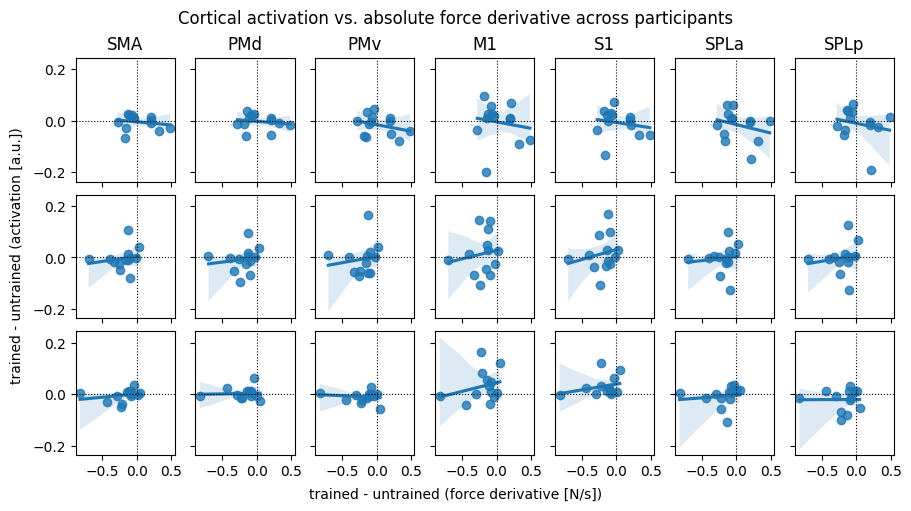

In [8]:
lin_model = {(roi, sess): [] for roi, sess in itertools.product(rois, gl.sessions)}

fig, axs = plt.subplots(len(gl.sessions), len(rois), constrained_layout=True, sharex=True, sharey=True, figsize=(9, 5))

for r, roi in enumerate(rois):
        for s, sess in enumerate(gl.sessions):
                ax = axs[s, r]
                y    = diff_sep[(diff_sep.Hem==H) & (diff_sep.roi==roi) & (diff_sep.session==sess)].Diff.to_numpy()
                x    = force_diff[force_diff.session==sess].force_der.to_numpy()
                data = pd.DataFrame(np.c_[x, y], columns=['force', 'neural'])

                lin_model[(roi, sess)] = smf.ols('y~x', data=data).fit()

                sb.regplot(data, x='force', y='neural', ax=ax)

                ax.set_title(roi if s==0 else None)
                ax.set_ylabel(None)
                ax.set_xlabel(None)
                ax.axhline(0, color='k', lw=.8, ls=':')
                ax.axvline(0, color='k', lw=.8, ls=':')

fig.supylabel('trained - untrained (activation [a.u.])', fontsize=10)
fig.supxlabel('trained - untrained (force derivative [N/s])', fontsize=10)

fig.suptitle('Cortical activation vs. absolute force derivative across participants')

records = []
for (roi, sess), res in lin_model.items():
        lo, hi = res.conf_int().loc['Intercept']
        records.append({
                'roi': roi,
                'session':    sess,
                'intercept':  res.params['Intercept'],
                'ci_low':     lo,
                'ci_high':    hi,
                'tval':       res.tvalues['Intercept'],
                'pval':       res.pvalues['Intercept'],
        })
intercepts               = pd.DataFrame(records)
intercepts['roi'] = pd.Categorical(intercepts.roi, categories=gl.rois[atlas], ordered=True)
intercepts.sort_values(by=['session', 'roi'], inplace=True)
print(intercepts)

plt.show()

      measure regionname  session  intercept    ci_low   ci_high      tval  \
0          ET        SMA        3  -0.002890 -0.019753  0.013972 -0.377271   
21         MD        SMA        3  -0.005481 -0.023287  0.012325 -0.677540   
42  force_abs        SMA        3  -0.005754 -0.024072  0.012564 -0.691409   
63  force_der        SMA        3  -0.004583 -0.022319  0.013152 -0.568806   
3          ET        PMd        3  -0.000461 -0.017544  0.016622 -0.059435   
..        ...        ...      ...        ...       ...       ...       ...   
80  force_der       SPLa       23  -0.004153 -0.036505  0.028199 -0.282519   
20         ET       SPLp       23  -0.006549 -0.044840  0.031742 -0.376441   
41         MD       SPLp       23  -0.013012 -0.056339  0.030315 -0.661000   
62  force_abs       SPLp       23  -0.017867 -0.044590  0.008856 -1.471579   
83  force_der       SPLp       23  -0.021143 -0.056156  0.013870 -1.329089   

        pval  
0   0.713149  
21  0.512062  
42  0.503639  
63 

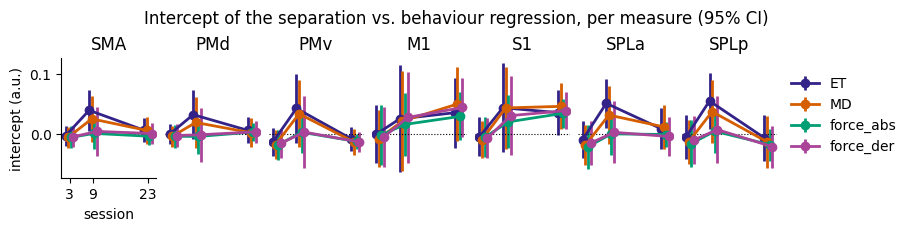

In [9]:
session   = diff_sep.session.unique()

# each behavioural measure plotted above, with the frame its column lives in
measures  = {'ET':        diff_behav,
             'MD':        diff_behav,
             'force_abs': force_diff,
             'force_der': force_diff}
hue_order = list(measures)
palette   = ['#332288', '#D55E00', '#009E73', '#AA4499']

records = []
for measure, df_behav in measures.items():
        for roi, sess in itertools.product(rois, session):
                y    = diff_sep[(diff_sep.Hem==H) & (diff_sep.roi==roi) & (diff_sep.session==sess)].Diff.to_numpy()
                x    = df_behav[df_behav.session==sess][measure].to_numpy()
                data = pd.DataFrame(np.c_[x, y], columns=['force', 'neural'])

                res    = smf.ols('y~x', data=data).fit()
                lo, hi = res.conf_int().loc['Intercept']
                records.append({
                        'measure':    measure,
                        'regionname': roi,
                        'session':    sess,
                        'intercept':  res.params['Intercept'],
                        'ci_low':     lo,
                        'ci_high':    hi,
                        'tval':       res.tvalues['Intercept'],
                        'pval':       res.pvalues['Intercept'],
                })

summary               = pd.DataFrame(records)
summary['regionname'] = pd.Categorical(summary.regionname, categories=gl.rois[atlas], ordered=True)
summary.sort_values(by=['session', 'regionname'], inplace=True)

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(9, 2.2), constrained_layout=True)

plot_ci_im_sess(fig, axs, summary, rois, y='intercept', x='session', ci=('ci_low', 'ci_high'), hue='measure', hue_order=hue_order, palette=palette, dodge=2, add_zero=True)

axs[0].set_ylabel('intercept (a.u.)')
axs[0].set_xlabel('session')
fig.legend(frameon=False, loc='outside right center')

fig.suptitle('Intercept of the separation vs. behaviour regression, per measure (95% CI)')

print(summary)

plt.show()